# Variational Autoencoder for Remote Sensing
**Assignment – Foundational Models and Generative AI**

> Name: Sarthak Baburao Narnor

> Roll No: g25ait1220

This notebook implements a Variational Autoencoder (VAE) for generating satellite imagery from the
EuroSAT dataset.

### 1. Import Libraries

In [1]:
# Import required libraries

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Check if GPU is available

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


### 2. Load EuroSAT Dataset
The EuroSAT dataset contains satellite images of land-use classes such as forests, highways, rivers, and residential areas.
Images are resized to **64×64 RGB**.

In [3]:
# Transform images

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

# Load dataset

dataset = torchvision.datasets.EuroSAT(
    root='./data',
    download=True,
    transform=transform
)

# DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

100%|██████████| 94.3M/94.3M [00:01<00:00, 59.8MB/s]


### 3. Visualize Dataset Samples

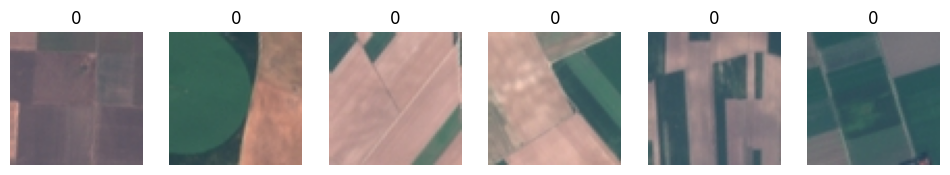

In [4]:
# Show sample satellite images

fig, ax = plt.subplots(1,6, figsize=(12,4))

for i in range(6):

    img, label = dataset[i]

    ax[i].imshow(img.permute(1,2,0))
    ax[i].set_title(label)
    ax[i].axis("off")

plt.show()

# Task 1: VAE Architecture

### 4. Encoder Network
The encoder compresses the input image into a **latent vector of size 32**.
It outputs:
- Mean (μ)
- Log variance (log σ²)

In [5]:
# Encoder compresses image → latent representation

latent_dim = 32 # Latent vector size

class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,4,2,1),
            nn.ReLU(),
            nn.Conv2d(32,64,4,2,1),
            nn.ReLU(),
            nn.Conv2d(64,128,4,2,1),
            nn.ReLU(),
            nn.Conv2d(128,256,4,2,1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(256*4*4, latent_dim)
        self.fc_logvar = nn.Linear(256*4*4, latent_dim)


    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

### 5. Reparameterization Trick
This trick enables sampling from the latent distribution while maintaining differentiability.

In [6]:
# Reparameterization trick allows gradient flow through sampling

def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    z = mu + eps * std
    return z

### 6. Decoder Network
The decoder reconstructs the original image from the latent vector.

In [7]:
# Decoder reconstructs image from latent vector

class Decoder(nn.Module):

    def __init__(self, latent_dim):

        super().__init__()

        self.fc = nn.Linear(latent_dim, 256*4*4)

        self.deconv = nn.Sequential(

            nn.ConvTranspose2d(256,128,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(128,64,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,32,4,2,1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,3,4,2,1),
            nn.Sigmoid()

        )


    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1,256,4,4)
        x = self.deconv(x)
        return x

### 7. VAE Model

In [8]:
# Combine encoder + decoder

class VAE(nn.Module):

    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)


    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

# Task 2: Training and Loss Function

### 8. VAE Loss Function
The loss consists of:
1. **Reconstruction Loss (MSE)**
2. **KL Divergence**

In [9]:
# VAE Loss = Reconstruction Loss + KL Divergence

def vae_loss(recon_x, x, mu, logvar):

    # Reconstruction Loss
    recon_loss = nn.functional.mse_loss(
        recon_x,
        x,
        reduction='sum'
    )

    # KL Divergence
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    # Normalize by batch size
    return (recon_loss + kl_loss) / x.size(0)

In [10]:
# Initialize model and optimizer

model = VAE(latent_dim).to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001
)

### 9. Training the Model

In [11]:
epochs = 20

losses = []

for epoch in range(epochs):
    total_loss = 0
    for images, _ in train_loader:
        images = images.to(device)
        recon, mu, logvar = model(images)
        loss = vae_loss(recon, images, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}: {avg_loss:.4f}")

Epoch 1: 165.8090
Epoch 2: 102.6272
Epoch 3: 94.1789
Epoch 4: 89.3332
Epoch 5: 86.9864
Epoch 6: 83.3491
Epoch 7: 81.1864
Epoch 8: 79.8239
Epoch 9: 79.2162
Epoch 10: 78.5348
Epoch 11: 78.1873
Epoch 12: 77.5900
Epoch 13: 77.4733
Epoch 14: 76.8025
Epoch 15: 76.5601
Epoch 16: 76.4715
Epoch 17: 75.9205
Epoch 18: 75.9255
Epoch 19: 75.5966
Epoch 20: 75.3000


### 10. Training Loss Curve

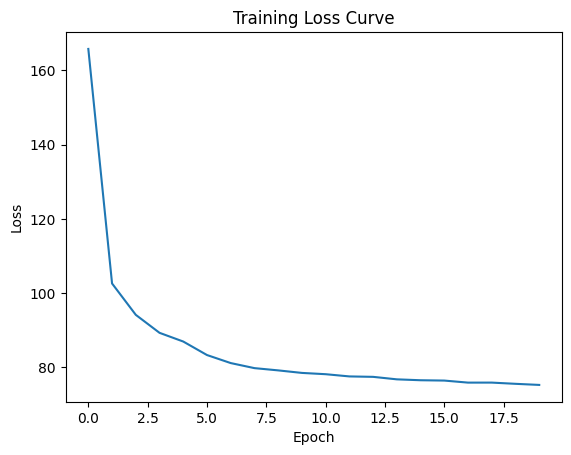

In [12]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

### 11. Generate Images from Random Latent Vectors

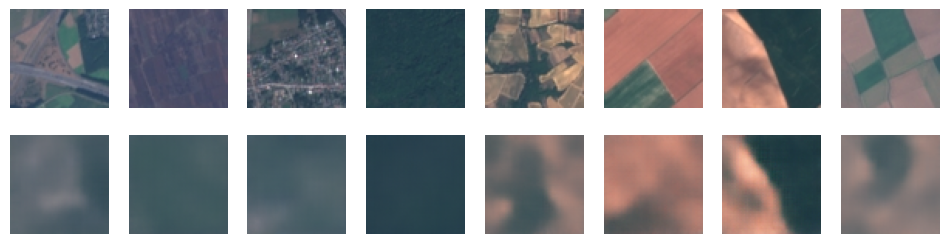

In [13]:
model.eval()

with torch.no_grad():
    imgs, _ = next(iter(train_loader))
    imgs = imgs[:8].to(device)
    recon, _, _ = model(imgs)

imgs = imgs.cpu()
recon = recon.cpu()

fig, ax = plt.subplots(2,8, figsize=(12,3))

for i in range(8):
    ax[0,i].imshow(imgs[i].permute(1,2,0))
    ax[0,i].axis("off")
    ax[1,i].imshow(recon[i].permute(1,2,0))
    ax[1,i].axis("off")

ax[0,0].set_ylabel("Original")
ax[1,0].set_ylabel("Reconstructed")
plt.show()

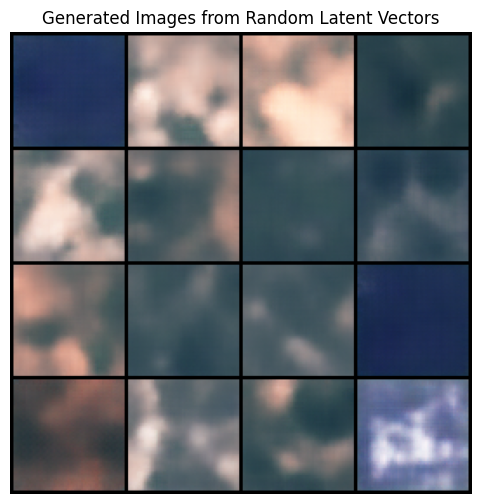

In [28]:
model.eval()

with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device) * 1.5
    samples = model.decoder(z).cpu()

grid = torchvision.utils.make_grid(samples, nrow=4)
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid.numpy(), (1,2,0)))
plt.title("Generated Images from Random Latent Vectors")
plt.axis("off");
plt.show()

# Task 3: Latent Space Interpolation

In [15]:
# Select two different images from dataset

img1, _ = dataset[10]     # example image 1
img2, _ = dataset[1500]   # example image 2

img1 = img1.unsqueeze(0).to(device)
img2 = img2.unsqueeze(0).to(device)

# Encode images into latent vectors

with torch.no_grad():
    mu1, _ = model.encoder(img1)
    mu2, _ = model.encoder(img2)

In [16]:
# Generate intermediate latent vectors

alphas = torch.linspace(0, 1, 10)
interpolations = []

with torch.no_grad():
    for a in alphas:
        z = (1 - a) * mu1 + a * mu2
        img = model.decoder(z)
        interpolations.append(img.cpu())

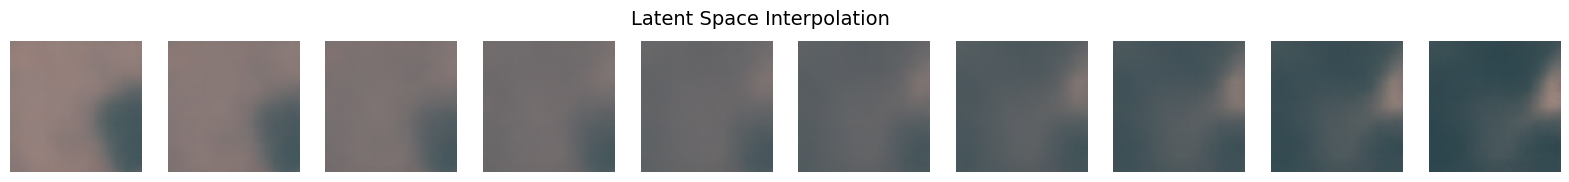

In [17]:
# Plot interpolation results

fig, ax = plt.subplots(1, 10, figsize=(20,2))

for i, img in enumerate(interpolations):
    ax[i].imshow(img.squeeze().cpu().permute(1,2,0))
    ax[i].axis("off")

plt.suptitle("Latent Space Interpolation", fontsize=14)
plt.show()

# Task 4: Semantic Vector Arithmetic

In [18]:
dataset.class_to_idx

{'AnnualCrop': 0,
 'Forest': 1,
 'HerbaceousVegetation': 2,
 'Highway': 3,
 'Industrial': 4,
 'Pasture': 5,
 'PermanentCrop': 6,
 'Residential': 7,
 'River': 8,
 'SeaLake': 9}

In [19]:
# Get class labels

class_map = dataset.class_to_idx

forest_label = class_map['Forest']
highway_label = class_map['Highway']
river_label = class_map['River']

In [20]:
forest_vectors = []

with torch.no_grad():
    for img, label in dataset:
        if label == forest_label:
            img = img.unsqueeze(0).to(device)
            mu, _ = model.encoder(img)
            forest_vectors.append(mu)

forest_mean = torch.mean(torch.cat(forest_vectors), dim=0)

In [21]:
highway_vectors = []

with torch.no_grad():
    for img, label in dataset:
        if label == highway_label:
            img = img.unsqueeze(0).to(device)
            mu, _ = model.encoder(img)
            highway_vectors.append(mu)

highway_mean = torch.mean(torch.cat(highway_vectors), dim=0)

In [22]:
# Highway - Forest gives paving direction

paving_direction = highway_mean - forest_mean

In [23]:
# Select first river image from dataset

for img, label in dataset:
    if label == river_label:
        river_img = img.unsqueeze(0).to(device)
        break

In [24]:
with torch.no_grad():
    river_latent, _ = model.encoder(river_img)
    # Apply paving direction
    new_latent = river_latent + 1* paving_direction
    result = model.decoder(new_latent)

In [25]:
difference = result.squeeze().cpu() - river_img.squeeze().cpu()

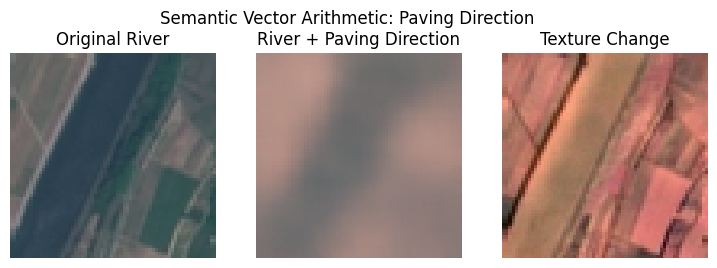

In [31]:
diff = difference.numpy()
diff = (diff - diff.min()) / (diff.max() - diff.min())

plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.imshow(river_img.squeeze().cpu().permute(1,2,0))
plt.title("Original River")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(result.squeeze().cpu().permute(1,2,0))
plt.title("River + Paving Direction")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(np.transpose(diff,(1,2,0)))
plt.title("Texture Change")
plt.axis("off")

plt.suptitle("Semantic Vector Arithmetic: Paving Direction", fontsize=12)
plt.show()

The VAE successfully learned representations of satellite imagery.
Interpolation results showed smooth transitions between land types.
Semantic vector arithmetic demonstrated that latent space captures
structural features such as vegetation and road textures.